# EAT (Luc)
Ik heb het EAT model gebruikt voor het extraheren van audio embeddings. EAT (Efficient Audio Transformer) is te vinden via HuggingFace (`worstchan/EAT-base_epoch30_pretrain`). De code van het model staat in de lokale `EAT/` map (gecloned van GitHub).

Net als de BEATs aanpak gebruik ik een pretrained audio model om 768-dimensionale embeddings te maken van elk geluidsbestand.

Verder gebruik ik een Autoencoder om anomalieën te detecteren op basis van reconstructiefout, het model leert normaal geluid reconstrueren, en geeft een hogere fout bij afwijkend geluid.

In [1]:
import os
import sys
import torch
import torchaudio
import numpy as np

# EAT code staat in de lokale EAT/ map (gecloned van GitHub: cwx-worst-one/EAT)
sys.path.insert(0, r"C:\Users\lucth\Downloads\Sorama Internship\EAT")

import torch.nn as nn
from transformers import AutoModel, AutoProcessor

c:\Users\lucth\miniconda3\envs\sorama\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Model laden
Hier wordt het EAT model geladen vanuit HuggingFace. De `AutoModel` klasse haalt automatisch de getrainde weights (checkpoint) op. Dit zijn de weights waarmee het model al getraind is op een grote audiodataset, wij hoeven het model dus niet zelf te trainen.

Als je een (NVIDIA) GPU hebt wordt CUDA automatisch gebruikt, anders draait het op de CPU.

In [2]:
# Laad het EAT model en de processor vanuit HuggingFace
MODEL_NAME = "worstchan/EAT-base_epoch30_pretrain"

import transformers

# Compatibiliteitspatch (wordt maar één keer toegepast)
# Probleem: EATModel definieert 'all_tied_weights_keys' als een list,
# maar transformers verwacht een dict:
#   - .update(...)  wordt aangeroepen in _adjust_tied_keys_with_tied_pointers
#   - .keys()       wordt aangeroepen in mark_tied_weights_as_initialized
# Oplossing: we zetten de waarde altijd om naar een dict vóór die aanroepen.
_PATCH_FLAG = "_eat_compat_patched"

if not getattr(transformers.PreTrainedModel, _PATCH_FLAG, False):
    _orig_adjust = transformers.PreTrainedModel.__dict__[
        "_adjust_tied_keys_with_tied_pointers"
    ]

    def _eat_adjust(self, missing_keys):
        v = self.__dict__.get("all_tied_weights_keys")
        # Zorg dat het altijd een dict is (niet een list of set)
        if not isinstance(v, dict):
            self.__dict__["all_tied_weights_keys"] = {}
        return _orig_adjust(self, missing_keys)

    transformers.PreTrainedModel._adjust_tied_keys_with_tied_pointers = _eat_adjust
    setattr(transformers.PreTrainedModel, _PATCH_FLAG, True)
    print("Compatibiliteitspatch toegepast.")
else:
    print("Patch was al actief, overgeslagen.")
# ───────────────────────────────────────────────────────────────────────────

eat_model = AutoModel.from_pretrained(MODEL_NAME, trust_remote_code=True)
eat_model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
eat_model.to(device)

print(f"Model geladen op: {device}")

Compatibiliteitspatch toegepast.


c:\Users\lucth\miniconda3\envs\sorama\lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Loading weights: 100%|██████████| 150/150 [00:00<00:00, 226.67it/s, Materializing param=model.pre_norm.weight]                   


Model geladen op: cuda


## MACs meten met thop

MACs (Multiply-Accumulate Operations) geven aan hoe rekenintensief het model is voor één inferentie. We gebruiken de `thop` library, die de forward-pass van het model analyseert met een dummy-input van dezelfde vorm als echte audio (een mel spectrogram van 512 tijdframes × 128 mel-kanalen).

Volgens de documentatie van de thop library telt thop niet altijd alle operaties in Transformer-modellen correct mee. De uitkomst is dan ook een ondergrens en niet volledig vergelijkbaar met de MACs voor convolutionele modellen zoals PANNs of MobileNetV3. Dus ik zou zeggen dat MAC de minst belangrijke evaluation metrics is vergeleken met de standaard (DCASE) evaluation metrics.


In [3]:
from thop import profile
import torch
import sys
import transformers
from transformers import AutoModel

device = "cuda" if torch.cuda.is_available() else "cpu"

if 'eat_model' not in globals():
    sys.path.insert(0, r"C:\Users\lucth\Downloads\Sorama Internship\EAT")

    _PATCH_FLAG = "_eat_compat_patched"
    if not getattr(transformers.PreTrainedModel, _PATCH_FLAG, False):
        _orig_adjust = transformers.PreTrainedModel.__dict__["_adjust_tied_keys_with_tied_pointers"]
        def _eat_adjust(self, missing_keys):
            if not isinstance(self.__dict__.get("all_tied_weights_keys"), dict):
                self.__dict__["all_tied_weights_keys"] = {}
            return _orig_adjust(self, missing_keys)
        transformers.PreTrainedModel._adjust_tied_keys_with_tied_pointers = _eat_adjust
        setattr(transformers.PreTrainedModel, _PATCH_FLAG, True)

    eat_model = AutoModel.from_pretrained("worstchan/EAT-base_epoch30_pretrain", trust_remote_code=True)
    eat_model.eval().to(device)
    print("eat_model geladen voor MACs-meting.")

# EAT verwacht een mel spectrogram van vorm [B, 1, T, F]
# Een 10-seconde clip geeft ~512 tijdframes met 128 mel-kanalen
dummy_input = torch.randn(1, 1, 512, 128).to(device)

macs, params = profile(eat_model, inputs=(dummy_input,), verbose=False)

eat_macs_gmacs = macs / 1e9
print(f"MACs        : {eat_macs_gmacs:.2f} GMACs")
print(f"Parameters  : {params / 1e6:.2f} M")
print()
print("Noot: thop telt attention-operaties in Transformers soms niet volledig mee.")
print("De werkelijke rekenbelasting kan hoger liggen dan de gemeten waarde.")


MACs        : 21.90 GMACs
Parameters  : 85.25 M

Noot: thop telt attention-operaties in Transformers soms niet volledig mee.
De werkelijke rekenbelasting kan hoger liggen dan de gemeten waarde.


## Data voorverwerken
Voordat een geluidsbestand door het EAT-model kan worden gestuurd, moet het eerst worden omgezet naar het juiste formaat. EAT verwacht geen ruwe audio, maar een **mel spectrogram**: een soort plaatje van het geluid waarbij de horizontale as de tijd voorstelt en de verticale as de frequentie.

Eerst wordt het wav-bestand ingeladen en omgezet naar **mono** (één kanaal in plaats van stereo) en **16.000 Hz** (16kHz). Dat laatste is de samplefrequentie, het aantal meetpunten per seconde. EAT is getraind op audio van 16kHz, dus andere samplefrequenties worden automatisch omgezet.

Daarna wordt het mel spectrogram berekend met de Kaldi fbank-methode. Dit verdeelt het geluid in 128 frequentiebanden (mel-kanalen) en kijkt hoe sterk elk van die frequenties aanwezig is, stap voor stap in de tijd. Het resultaat is een matrix van tijdstappen × frequentiebanden.

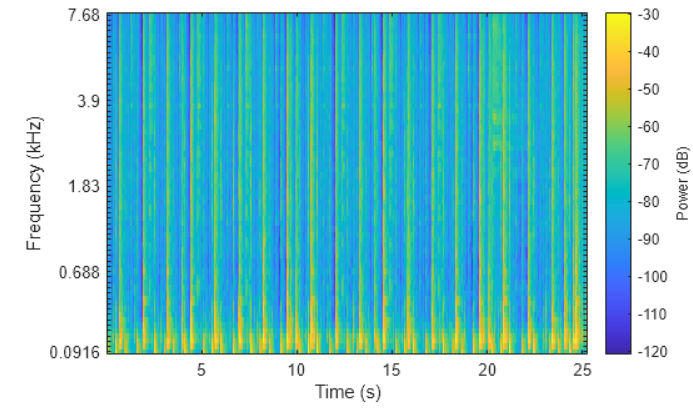

*Afbeelding 1: Een voorbeeld van een mel spectrogram (MATLAB, n.d.). De horizontale as is tijd, de verticale as is frequentie op de mel-schaal (die beter aansluit bij hoe het menselijk oor geluid waarneemt), en de kleur geeft de energie aan (hoe feller, hoe sterker die frequentie aanwezig is).*

Vervolgens wordt de spectrogram op een vaste lengte van 512 tijdframes gebracht: te korte opnames worden aangevuld met nullen (padding), te lange worden afgeknipt. Tot slot wordt alles genormaliseerd, de waarden worden verschoven en geschaald met vaste getallen afkomstig uit de originele EAT-training, zodat de invoer dezelfde schaal heeft als waarop het model getraind is.

In [4]:
TARGET_LENGTH = 512   # aantal frames in de tijdas
NORM_MEAN = -4.268    # gemiddelde voor normalisatie (van EAT training)
NORM_STD = 4.569      # standaarddeviatie voor normalisatie

def wav_to_mel(wav_path, target_length=TARGET_LENGTH):
    """Laad een wav-bestand en zet het om naar een mel spectrogram."""
    waveform, sr = torchaudio.load(wav_path)

    # Omzetten naar mono
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    # Resample naar 16kHz (wat EAT verwacht)
    if sr != 16000:
        waveform = torchaudio.functional.resample(waveform, sr, 16000)

    # Bereken Kaldi fbank mel spectrogram (128 kanalen)
    fbank = torchaudio.compliance.kaldi.fbank(
        waveform,
        htk_compat=True,
        sample_frequency=16000,
        use_energy=False,
        window_type='hanning',
        num_mel_bins=128,
        dither=0.0,
        frame_shift=10
    )  # vorm: [T, 128]

    # Pad of trim naar vaste lengte
    T = fbank.shape[0]
    if T < target_length:
        fbank = torch.nn.functional.pad(fbank, (0, 0, 0, target_length - T))
    else:
        fbank = fbank[:target_length, :]

    # Normaliseer
    fbank = (fbank - NORM_MEAN) / (NORM_STD * 2)

    # Voeg batch- en kanaal-dimensie toe: [1, 1, T, 128]
    return fbank.unsqueeze(0).unsqueeze(0)


def extract_eat_embedding(wav_path):
    """Geeft een 768-dimensionale embedding terug voor een wav-bestand."""
    mel = wav_to_mel(wav_path).to(device)
    with torch.no_grad():
        # De HuggingFace EATModel.extract_features() accepteert alleen x (geen padding_mask)
        # en geeft een tensor terug van vorm [B, T, 768].
        # We pakken het CLS-token (positie 0) als representatie voor het hele clip.
        out = eat_model.extract_features(mel)  # vorm: [1, T, 768]
        embedding = out[:, 0, :].squeeze(0).cpu().numpy()  # [768]
    return embedding

## Embeddings extraheren uit de trainingsdata
Nu heeft het EAT model 768 features voor elk geluidsbestand gehaald. Deze embeddings worden opgeslagen als `.npy` bestanden zodat we ze later opnieuw kunnen gebruiken zonder het model elke keer opnieuw te draaien.

In [5]:
input_folder = r"C:\Users\lucth\Downloads\Sorama Internship\Files Development Dataset\bearing\train"
output_folder = r"C:\Users\lucth\Downloads\Sorama Internship\Luc_EAT_features\bearing"
os.makedirs(output_folder, exist_ok=True)

for root, _, files in os.walk(input_folder):
    for file in files:
        if file.endswith(".wav"):
            file_path = os.path.join(root, file)
            embedding = extract_eat_embedding(file_path)

            # Spiegel de mappenstructuur naar de output folder
            relative_path = os.path.relpath(root, input_folder)
            out_dir = os.path.join(output_folder, relative_path)
            os.makedirs(out_dir, exist_ok=True)

            out_path = os.path.join(out_dir, os.path.splitext(file)[0] + ".npy")
            np.save(out_path, embedding)

            print(f"Verwerkt: {file} -> {out_path}")

print("Alle embeddings succesvol geëxtraheerd")

Verwerkt: section_00_source_train_normal_0000_noAttribute.wav -> C:\Users\lucth\Downloads\Sorama Internship\Luc_EAT_features\bearing\.\section_00_source_train_normal_0000_noAttribute.npy
Verwerkt: section_00_source_train_normal_0001_noAttribute.wav -> C:\Users\lucth\Downloads\Sorama Internship\Luc_EAT_features\bearing\.\section_00_source_train_normal_0001_noAttribute.npy
Verwerkt: section_00_source_train_normal_0002_noAttribute.wav -> C:\Users\lucth\Downloads\Sorama Internship\Luc_EAT_features\bearing\.\section_00_source_train_normal_0002_noAttribute.npy
Verwerkt: section_00_source_train_normal_0003_noAttribute.wav -> C:\Users\lucth\Downloads\Sorama Internship\Luc_EAT_features\bearing\.\section_00_source_train_normal_0003_noAttribute.npy
Verwerkt: section_00_source_train_normal_0004_noAttribute.wav -> C:\Users\lucth\Downloads\Sorama Internship\Luc_EAT_features\bearing\.\section_00_source_train_normal_0004_noAttribute.npy
Verwerkt: section_00_source_train_normal_0005_noAttribute.wav -> 

## Autoencoder trainen (anomaliedetectie)
Een Autoencoder is een neuraal netwerk dat leert om zijn input te reconstrueren. We trainen hem alleen op **normaal** geluid. Vervolgens zal hij bij **abnormaal** geluid een hogere reconstructiefout hebben, dat is dan het anomaliesignaal.

De architectuur is identiek aan die van Job:
- **Encoder**: 768 → 64 (comprimeert de embedding)
- **Decoder**: 64 → 768 (reconstrueert de originele embedding)

In [6]:
from torch.utils.data import DataLoader, TensorDataset

# 1. Laad alle opgeslagen embeddings 
all_files = []
for root, _, files in os.walk(output_folder):
    for file in files:
        if file.endswith(".npy"):
            all_files.append(os.path.join(root, file))

embeddings_list = []
file_paths = []
for f in all_files:
    emb = np.load(f)
    embeddings_list.append(emb)
    file_paths.append(f)

X = np.stack(embeddings_list)          # vorm: [N, 768]
X = torch.tensor(X, dtype=torch.float32)
print("Geladen embeddings vorm:", X.shape)

#  2. Definieer de Autoencoder (zelfde als Job) 
class AE(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

# 3. DataLoader aanmaken 
batch_size = 32
dataset = TensorDataset(X)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

#  4. Model initialiseren 
ae = AE().to(device)
optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# 5. Autoencoder trainen 
epochs = 50
for epoch in range(epochs):
    epoch_loss = 0
    for batch in loader:
        x_batch = batch[0].to(device)
        optimizer.zero_grad()
        x_hat = ae(x_batch)
        loss = loss_fn(x_hat, x_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * x_batch.size(0)
    epoch_loss /= len(loader.dataset)
    if epoch % 10 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch+1}/{epochs}  Loss: {epoch_loss:.6f}")

print(" Autoencoder klaar met trainen")

Geladen embeddings vorm: torch.Size([1000, 768])
Epoch 1/50  Loss: 0.002201
Epoch 11/50  Loss: 0.000042
Epoch 21/50  Loss: 0.000032
Epoch 31/50  Loss: 0.000026
Epoch 41/50  Loss: 0.000022
Epoch 50/50  Loss: 0.000020
 Autoencoder klaar met trainen


## Anomaliescores berekenen en opslaan
Nu berekenen we voor elk geluidsbestand hoe groot de reconstructiefout is. Een hoge fout = waarschijnlijk een anomalie. De resultaten worden opgeslagen in een CSV-bestand.

In [7]:
import csv

output_csv = r"C:\Users\lucth\Downloads\Sorama Internship\Luc_EAT_features\anomaly_scores.csv"

# zet model in evaluatiemodus (geen gradient-berekeningen)
ae.eval()
scores = []

with torch.no_grad():
    for emb, path in zip(X, file_paths):
        emb = emb.to(device)
        recon = ae(emb)
        score = torch.norm(emb - recon).item()  # L2 reconstructiefout = anomaliescore
        scores.append((path, score))

# sla de scores op in een CSV-bestand
with open(output_csv, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["bestand", "anomaliescore"])
    writer.writerows(scores)

print(f"Anomaliescores opgeslagen in: {output_csv}")

# toon de 5 hoogste scores (meest waarschijnlijke anomalieën)
scores_sorted = sorted(scores, key=lambda x: x[1], reverse=True)
print("\nTop 5 hoogste anomaliescores:")
for path, score in scores_sorted[:5]:
    print(f"  {os.path.basename(path)}: {score:.4f}")

Anomaliescores opgeslagen in: C:\Users\lucth\Downloads\Sorama Internship\Luc_EAT_features\anomaly_scores.csv

Top 5 hoogste anomaliescores:
  section_00_source_train_normal_0538_noAttribute.npy: 0.2210
  section_00_source_train_normal_0891_noAttribute.npy: 0.2203
  section_00_source_train_normal_0242_noAttribute.npy: 0.2119
  section_00_source_train_normal_0861_noAttribute.npy: 0.2094
  section_00_target_train_normal_0001_noAttribute.npy: 0.2024


## Evaluation metrics

Om de modellen eerlijk te vergelijken evalueren we op de gelabelde bearing testset uit de DCASE development dataset. De bestandsnamen bevatten het label (normal of anomaly), dus er is geen apart labelbestand nodig. Evalueren op de gelabelde testset is het doel van de development dataset, DCASE stelt deze bestanden (100 normaal + 100 anomalie per machine type) beschikbaar zodat deelnemers hun systeem kunnen meten of het model werkt vóór de echte inzending. 

(De "unsupervised" eis geldt dus alleen voor training, het model mag tijdens het leren nooit anomaliebestanden zien)

AUC (Area Under the ROC Curve) meet hoe goed het model anomalieën scheidt van normale geluiden over alle mogelijke drempelwaarden. Een score van 1.0 is perfect, 0.5 staat gelijk aan willekeurig raden.

pAUC is de partial AUC bij een false positive rate van maximaal 10%. Dit is de officiële DCASE-metric, omdat in de praktijk alleen het gedeelte van de ROC-curve met weinig valse alarmen relevant is.

Voor accuracy, precision, recall en F1 is een vaste drempelwaarde nodig. We gebruiken het 95e percentiel van de trainingsscores: alles daarboven geldt als anomalie.

MACs (Multiply-Accumulate Operations) meten de rekenkundige zwaarte van het feature extractor model. EAT is een Transformer-model en daarvoor is een directe thop-meting niet altijd betrouwbaar.

(De drempelwaarde beïnvloedt alleen accuracy, precision, recall en F!)

In [8]:
import os
import numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

TEST_DIR = r"C:\Users\lucth\Downloads\Sorama Internship\Files Development Dataset\bearing\test"

# trainingsscores voor drempelwaardebepaling (95e percentiel)
train_scores_raw = [s for _, s in scores]
threshold = np.percentile(train_scores_raw, 95)

# evaluatie op testset
test_scores = []
test_labels = []

ae.eval()
for filename in sorted(os.listdir(TEST_DIR)):
    if not filename.endswith('.wav'):
        continue
    if 'anomaly' in filename:
        label = 1
    elif 'normal' in filename:
        label = 0
    else:
        continue

    embedding = extract_eat_embedding(os.path.join(TEST_DIR, filename))
    import torch
    emb_tensor = torch.tensor(embedding, dtype=torch.float32).to(device)
    with torch.no_grad():
        score = torch.norm(emb_tensor - ae(emb_tensor)).item()

    test_scores.append(score)
    test_labels.append(label)

test_scores = np.array(test_scores)
test_labels = np.array(test_labels)
y_pred = (test_scores >= threshold).astype(int)

auc  = roc_auc_score(test_labels, test_scores)
pauc = roc_auc_score(test_labels, test_scores, max_fpr=0.1)
acc  = accuracy_score(test_labels, y_pred)
prec = precision_score(test_labels, y_pred, zero_division=0)
rec  = recall_score(test_labels, y_pred, zero_division=0)
f1   = f1_score(test_labels, y_pred, zero_division=0)

print(f"testset: {len(test_labels)} bestanden  |  anomalieën: {test_labels.sum()}  |  normaal: {(test_labels == 0).sum()}")
print(f"\nresultaten EAT-base (drempelwaarde = {threshold:.4f}):")
print(f"  AUC       : {auc:.4f}")
print(f"  pAUC      : {pauc:.4f}  (FPR ≤ 10%, DCASE-standaard)")
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-score  : {f1:.4f}")

eat_results = {
    'model': 'EAT-base',
    'AUC': round(auc, 4), 'pAUC': round(pauc, 4),
    'Accuracy': round(acc, 4), 'Precision': round(prec, 4),
    'Recall': round(rec, 4), 'F1': round(f1, 4),
    'threshold': round(threshold, 4),
}
print(f"\neat_results = {eat_results}")


testset: 200 bestanden  |  anomalieën: 100  |  normaal: 100

resultaten EAT-base (drempelwaarde = 0.1640):
  AUC       : 0.5969
  pAUC      : 0.5574  (FPR ≤ 10%, DCASE-standaard)
  Accuracy  : 0.5550
  Precision : 0.6667
  Recall    : 0.2200
  F1-score  : 0.3308

eat_results = {'model': 'EAT-base', 'AUC': 0.5969, 'pAUC': 0.5574, 'Accuracy': 0.555, 'Precision': 0.6667, 'Recall': 0.22, 'F1': 0.3308, 'threshold': np.float64(0.164)}


**References**

Afbeelding 1: Mel spectrogram - MATLAB. (n.d.). https://nl.mathworks.com/help/audio/ref/melspectrogram.html
